Solved version of the notebook.

# Exercise 1: Ternary classification with predesigned features

In this exercise, you will classify the MNIST digits **1**, **6**, and **7** using a simple neural network and **handcrafted features**.

You will compare two feature designs:

1. **Average gray value** together with the **mean horizontal edge value**
2. **Mean horizontal edge value** together with the **mean vertical edge value**

Your goal is to:
- extract the features,
- train a classifier,
- evaluate both variants,
- compare the results.


## Learning goals

After this exercise, you should be able to:

- compute simple handcrafted image features,
- build feature vectors from image statistics,
- train a neural network for multiclass classification,
- compare different feature choices experimentally.

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from tensorflow.keras.datasets import mnist

## Step 1: Load and preprocess the MNIST data

We load the MNIST dataset and normalize the image values to the range $[0,1]$.

In [2]:

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train_norm = x_train.astype(np.float32) / 255.0
x_test_norm  = x_test.astype(np.float32) / 255.0

y_train = torch.from_numpy(y_train)
y_test = torch.from_numpy(y_test)

print("Training images:", x_train_norm.shape)
print("Test images:", x_test_norm.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Test images: (10000, 28, 28)


## Step 2: Horizontal edge image

The following function computes a simple horizontal edge image by taking absolute differences between neighboring rows.

In [3]:

def horizontal_edge_image(img):
    edge = np.zeros_like(img, dtype=np.float32)
    edge[:-1, :] = np.abs(img[1:, :] - img[:-1, :])
    return edge

def vertical_edge_image(img):
    img=np.transpose(img,(1,0))
    edge=horizontal_edge_image(img)
    edge=np.transpose(edge,(1,0))
    return edge

## Step 3: Inspect edge images

Apply both edge transforms to one example image and visualize:
- the original image,
- the corresponding horizontal edge image,
- the corresponding vertical edge image.


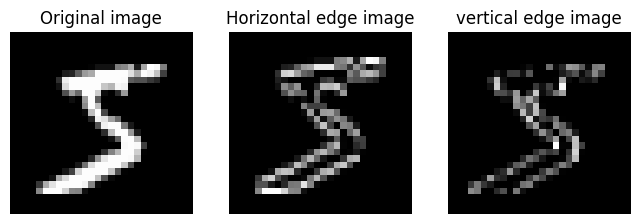

In [4]:

idx = 0
example_img = x_train_norm[idx]
example_edge_horizontal = horizontal_edge_image(example_img)
example_edge_vertical = vertical_edge_image(example_img)


fig, axes = plt.subplots(1, 3, figsize=(8, 4))
axes[0].imshow(example_img, cmap="gray")
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(example_edge_horizontal, cmap="gray")
axes[1].set_title("Horizontal edge image")
axes[1].axis("off")

axes[2].imshow(example_edge_vertical, cmap="gray")
axes[2].set_title("vertical edge image")
axes[2].axis("off")

plt.show()

## Step 4: Feature extraction

For each image, we compute the following quantities:

- average gray value,
- mean horizontal edge value,
- mean vertical edge value.

These will later be combined into two different 2D feature representations.


In [5]:

edge_imgs_horizontal_train = np.array([horizontal_edge_image(img) for img in x_train_norm])
edge_imgs_horizontal_test = np.array([horizontal_edge_image(img) for img in x_test_norm])

edge_imgs_vertical_train = np.array([vertical_edge_image(img) for img in x_train_norm])
edge_imgs_vertical_test = np.array([vertical_edge_image(img) for img in x_test_norm])

print(edge_imgs_horizontal_train.shape, edge_imgs_horizontal_test.shape)

(60000, 28, 28) (10000, 28, 28)


In [6]:

avg_gray_train = x_train_norm.mean(axis=(1, 2))
avg_gray_test = x_test_norm.mean(axis=(1, 2))

print(avg_gray_train.shape, avg_gray_test.shape)

(60000,) (10000,)


In [7]:

avg_edge_horizontal_train = edge_imgs_horizontal_train.mean(axis=(1, 2))
avg_edge_horizontal_test =  edge_imgs_horizontal_test.mean(axis=(1, 2))

avg_edge_vertical_train = edge_imgs_vertical_train.mean(axis=(1, 2))
avg_edge_vertical_test =  edge_imgs_vertical_test.mean(axis=(1, 2))



print(avg_edge_horizontal_train.shape, avg_edge_vertical_train.shape)

(60000,) (60000,)


## Step 5: Build feature matrices

We now combine the extracted quantities into two different input representations:

- `X_1`: uses **average gray value** + **mean horizontal edge value**
- `X_2`: uses **mean horizontal edge value** + **mean vertical edge value**


In [8]:

X_mean_horizontal_train = torch.stack((
    torch.from_numpy(avg_gray_train),
    torch.from_numpy(avg_edge_horizontal_train)
), dim=1)

X_mean_horizontal_test = torch.stack((
    torch.from_numpy(avg_gray_test),
    torch.from_numpy(avg_edge_horizontal_test)
), dim=1)

X_horizontal_vertical_train = torch.stack((
    torch.from_numpy(avg_edge_horizontal_train),
    torch.from_numpy(avg_edge_vertical_train)
), dim=1)

X_horizontal_vertical_test = torch.stack((
    torch.from_numpy(avg_edge_horizontal_test),
    torch.from_numpy(avg_edge_vertical_test)
), dim=1)

print(X_mean_horizontal_train.shape)
print(X_horizontal_vertical_train.shape)

torch.Size([60000, 2])
torch.Size([60000, 2])


## Step 6: Select the ternary classification problem

We restrict the dataset to the digits **1**, **6**, and **7**.
The labels are encoded as one-hot vectors in the order:

- class 0 -> digit 1
- class 1 -> digit 6
- class 2 -> digit 7

In [9]:

DIGITS = [1, 6, 7]

mask_train = torch.logical_or(y_train == 1, y_train == 6)
mask_train = torch.logical_or(mask_train, y_train == 7)

mask_test = torch.logical_or(y_test == 1, y_test == 6)
mask_test = torch.logical_or(mask_test, y_test == 7)

def one_hot_167(labels):
    return torch.stack((
        (labels == 1).float(),
        (labels == 6).float(),
        (labels == 7).float()
    ), dim=1)

Y_train = one_hot_167(y_train[mask_train])
Y_test = one_hot_167(y_test[mask_test])

X_1_train_ternary = X_mean_horizontal_train[mask_train]
X_1_test_ternary = X_mean_horizontal_test[mask_test]

X_2_train_ternary = X_horizontal_vertical_train[mask_train]
X_2_test_ternary = X_horizontal_vertical_test[mask_test]

print("Mean-horizontal training shape:", X_1_train_ternary.shape)
print("Horizontal-vertical training shape:", X_2_train_ternary.shape)
print("Label shape:", Y_train.shape)

Mean-horizontal training shape: torch.Size([18925, 2])
Horizontal-vertical training shape: torch.Size([18925, 2])
Label shape: torch.Size([18925, 3])


## Step 7: Define the classifier

We use a small feedforward neural network with one hidden layer.

In [10]:

class FeedforwardNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return torch.softmax(x, dim=1)

## Step 8: Implement a training function

Write a function that:
- creates a model,
- trains it on the given training data,
- returns the trained model.

In [11]:

def train_model(X_train, Y_train, hidden_size=100, lr=0.01, num_epochs=1000):
    model = FeedforwardNet(2, hidden_size, 3)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(num_epochs):
        outputs = model(X_train.float())
        loss = -(Y_train * torch.log(outputs + 1e-10)).sum(dim=1).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 200 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

    return model

## Step 9: Implement an evaluation function

Write a function that computes the classification accuracy.

In [12]:

def compute_accuracy(model, X, Y):
    model.eval()
    with torch.no_grad():
        outputs = model(X.float())
        _, predicted_labels = torch.max(outputs, 1)
        _, true_labels = torch.max(Y, 1)
        accuracy = torch.mean((predicted_labels == true_labels).float())
    return 100 * accuracy.item()

## Step 10: Train and compare both models

Train one model with the feature representation `X_1` and one model with the feature representation `X_2`.
Then compare their test accuracies.


In [13]:

model_mean_horizontal = train_model(X_1_train_ternary, Y_train)

Epoch [200/1000], Loss: 0.5827
Epoch [400/1000], Loss: 0.5549
Epoch [600/1000], Loss: 0.5543
Epoch [800/1000], Loss: 0.5536
Epoch [1000/1000], Loss: 0.5530


In [14]:

model_horizontal_vertical = train_model(X_2_train_ternary, Y_train)

Epoch [200/1000], Loss: 0.4725
Epoch [400/1000], Loss: 0.4080
Epoch [600/1000], Loss: 0.4025
Epoch [800/1000], Loss: 0.4020
Epoch [1000/1000], Loss: 0.4015


In [15]:
acc_1 = compute_accuracy(model_mean_horizontal, X_1_test_ternary, Y_test)
acc_2 = compute_accuracy(model_horizontal_vertical, X_2_test_ternary, Y_test)

print(f"Accuracy using average gray + mean horizontal edge: {acc_1:.2f}%")
print(f"Accuracy using mean horizontal + mean vertical edge: {acc_2:.2f}%")


Accuracy using average gray + mean horizontal edge: 73.21%
Accuracy using mean horizontal + mean vertical edge: 83.18%


## Step 11: Reflection

Answer the following questions:

1. Which feature representation performs better?
2. How does adding vertical edge information change the classification problem?
3. Do you think these handcrafted features are sufficient to separate the digits well? Why or why not?


## Optional: Visualize the feature spaces

Create scatter plots for the two feature representations:
- average gray value vs mean horizontal edge value,
- mean horizontal edge value vs mean vertical edge value.

Color the points by digit label.


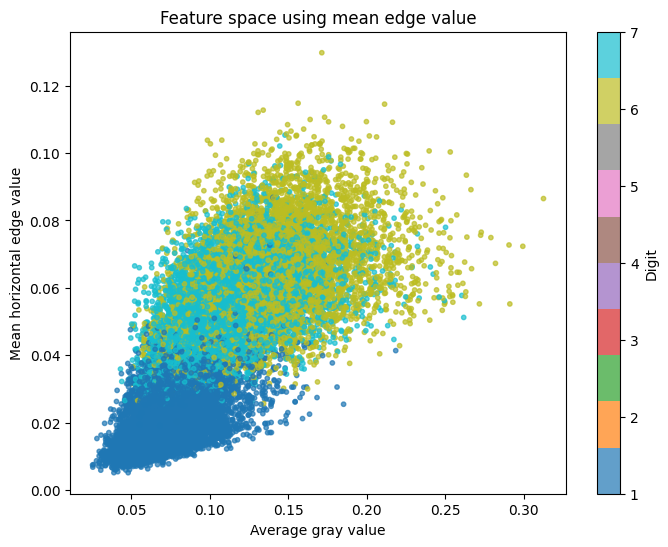

In [16]:

plt.figure(figsize=(8, 6))
plt.scatter(
    X_1_train_ternary[:, 0].numpy(),
    X_1_train_ternary[:, 1].numpy(),
    c=y_train[mask_train].numpy(),
    cmap="tab10",
    s=10,
    alpha=0.7
)
plt.xlabel("Average gray value")
plt.ylabel("Mean horizontal edge value")
plt.title("Feature space using mean edge value")
plt.colorbar(label="Digit")
plt.show()

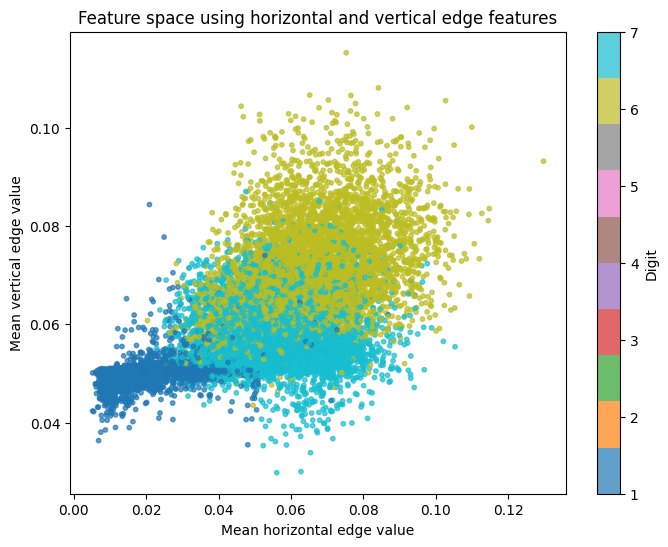

In [17]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_2_train_ternary[:, 0].numpy(),
    X_2_train_ternary[:, 1].numpy(),
    c=y_train[mask_train].numpy(),
    cmap="tab10",
    s=10,
    alpha=0.7
)
plt.xlabel("Mean horizontal edge value")
plt.ylabel("Mean vertical edge value")
plt.title("Feature space using horizontal and vertical edge features")
plt.colorbar(label="Digit")
plt.show()
